## Project1/Milestone 3: Customer Churn Prediction
Class: "DSC680-T301 Applied Data Science (2267-1)<br>
Student: "Roshan GC" <br>
Professor: "Ashton Xu" <br>
Date: "08/23/2026"

## Description
This notebook contains the Python code used for data analysis and Customer Churn Prediction.

## Import required libraries and load dataset

In [60]:
# importing required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [61]:
# Load dataset
df = pd.read_csv("/users/roshan/DSC680/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preview data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Check the data

In [62]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

df.info()

Dataset Shape: (7043, 21)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  

# Clean Total charges

In [63]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()

print(df.shape)

(7032, 21)


## Exploratory Data Analysis

In [64]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


## Visualization

# Chart 1 – Customer Churn Distribution

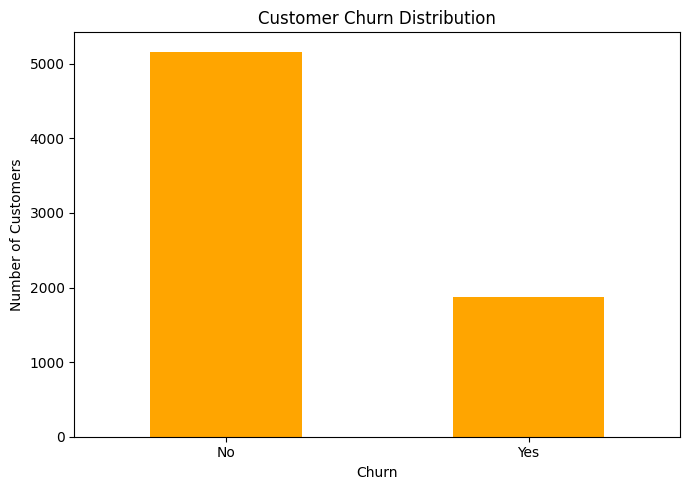

In [65]:
# Chart 1: Customer Churn Distribution
plt.figure(figsize=(7, 5))
df["Churn"].value_counts().plot(kind="bar", color="orange")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Chart 2: Churn by Contract Type

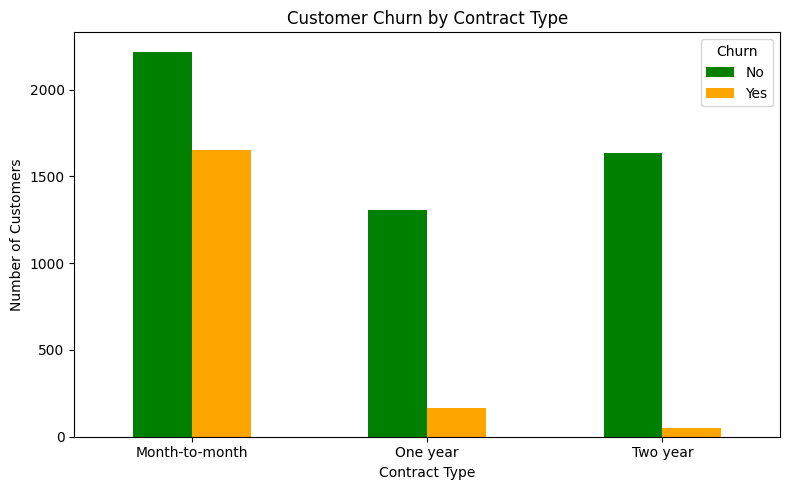

In [66]:
# Chart 2: Churn by Contract Type
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(
    kind="bar",
    figsize=(8, 5),
    color=["green", "orange"]
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [67]:
contract_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_rate.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


# Chart 3: Tenure by Churn

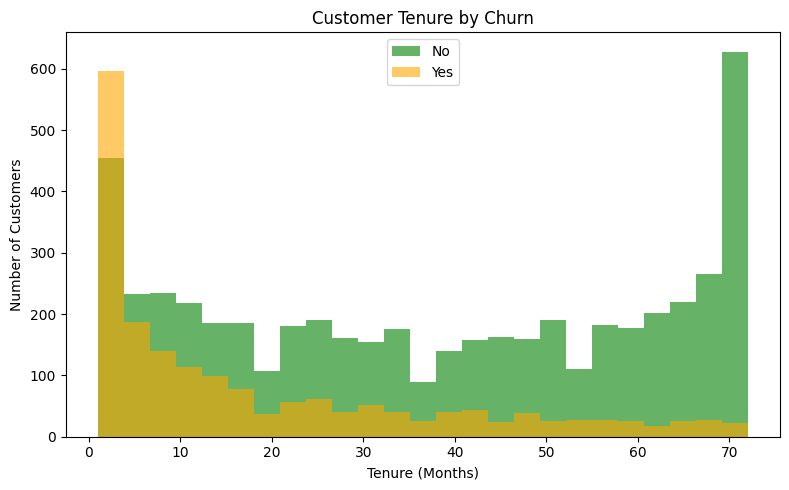

In [70]:
# Chart 3: Customer Tenure by Churn
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Churn"] == "No"]["tenure"],
    bins=25,
    alpha=0.6,
    label="No",
    color="green"
)

plt.hist(
    df[df["Churn"] == "Yes"]["tenure"],
    bins=25,
    alpha=0.6,
    label="Yes",
    color="orange"
)

plt.title("Customer Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
print(df.groupby("Churn")["tenure"].mean().round(2))

Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64


# Chart 4: Monthly Charges by Churn

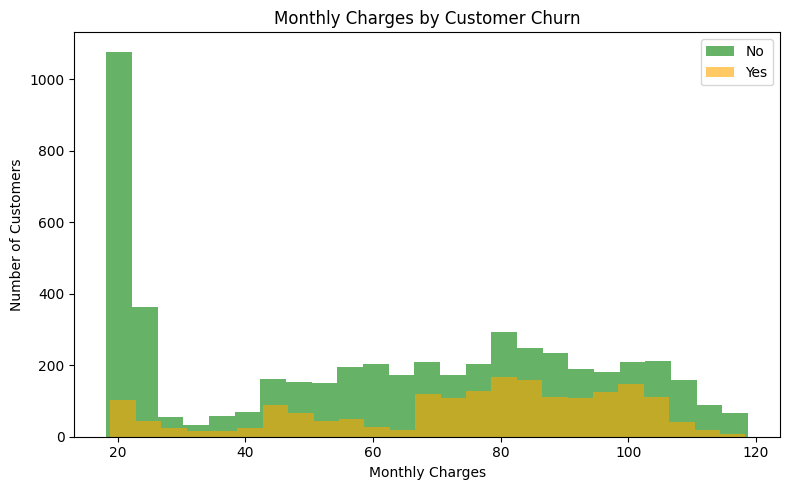

In [72]:
# Chart 4: Monthly Charges by Churn
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Churn"] == "No"]["MonthlyCharges"],
    bins=25,
    alpha=0.6,
    label="No",
    color="green"
)

plt.hist(
    df[df["Churn"] == "Yes"]["MonthlyCharges"],
    bins=25,
    alpha=0.6,
    label="Yes",
    color="orange"
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()
plt.show()

In [73]:
print(df.groupby("Churn")["MonthlyCharges"].mean().round(2))

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


# Chart 5: Churn by Internet Service

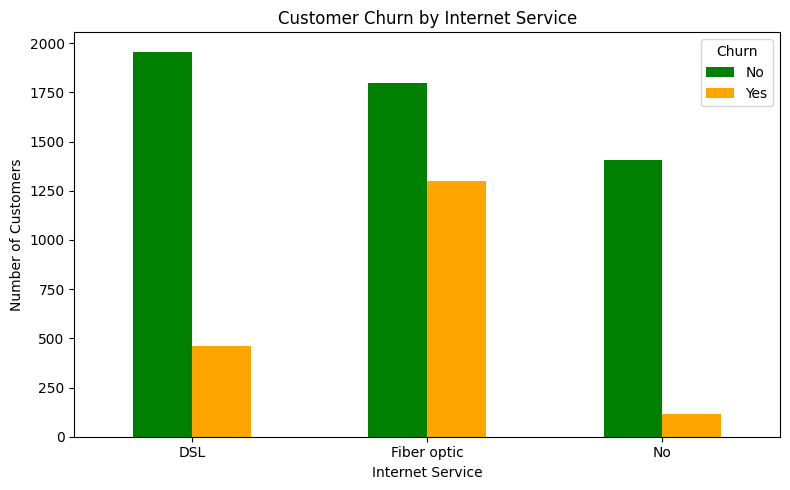

In [74]:
# Chart 5: Churn by Internet Service
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_churn.plot(
    kind="bar",
    figsize=(8, 5),
    color=["green", "orange"]
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [75]:
internet_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_rate.round(2))

Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


# Machine Learning

## Data prepatation

In [76]:
# Remove customer ID
df = df.drop("customerID", axis=1)

# Convert target variable to numbers
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Convert categorical variables into numeric variables
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Separate Feature and Target

In [77]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Train/Test Split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 5625
Testing Records: 1407


## Logistic Regression

## Train Logistic Regression

In [79]:
log_model = LogisticRegression(max_iter=3000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

## Logistic Regression Results

In [80]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Logistic Regression Results")
print("Accuracy:", round(log_accuracy, 3))
print("Precision:", round(log_precision, 3))
print("Recall:", round(log_recall, 3))
print("F1-score:", round(log_f1, 3))

Logistic Regression Results
Accuracy: 0.805
Precision: 0.65
Recall: 0.575
F1-score: 0.61


## Decision Tree

In [97]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

## Decision Tree Results

In [98]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("Accuracy:", round(dt_accuracy, 3))
print("Precision:", round(dt_precision, 3))
print("Recall:", round(dt_recall, 3))
print("F1-score:", round(dt_f1, 3))

Decision Tree Results
Accuracy: 0.719
Precision: 0.47
Recall: 0.463
F1-score: 0.466


## Random Forest

## Train Random Forest

In [99]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## Random Forest Result

In [100]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1-score:", round(rf_f1, 3))

Random Forest Results
Accuracy: 0.787
Precision: 0.622
Recall: 0.511
F1-score: 0.561


# Model Comparison

In [101]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        dt_recall,
        rf_recall
    ],
    "F1-Score": [
        log_f1,
        dt_f1,
        rf_f1
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.805,0.650,0.575,0.610
1,Decision Tree,0.719,0.470,0.463,0.466
2,Random Forest,0.787,0.622,0.511,0.561


## Cross Validation

## Logistic Regression Cross-Validation

In [103]:
from sklearn.model_selection import cross_val_score

log_cv = cross_val_score(
    log_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression Cross-Validation:")
print(log_cv.round(3))
print("Average Accuracy:", round(log_cv.mean(), 3))

Logistic Regression Cross-Validation:
[0.802 0.812 0.791 0.809 0.803]
Average Accuracy: 0.804


## Decision Tree Cross-Validation

In [104]:
dt_cv = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree Cross-Validation:")
print(dt_cv.round(3))
print("Average Accuracy:", round(dt_cv.mean(), 3))

Decision Tree Cross-Validation:
[0.729 0.736 0.726 0.732 0.734]
Average Accuracy: 0.732


## Random Forest Cross-Validation

In [105]:
rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest Cross-Validation:")
print(rf_cv.round(3))
print("Average Accuracy:", round(rf_cv.mean(), 3))

Random Forest Cross-Validation:
[0.803 0.794 0.773 0.799 0.794]
Average Accuracy: 0.793


## Hyperparameter Testing

## Tune Random Forest

In [108]:

from sklearn.model_selection import GridSearchCV
parameters = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parameters,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


## Show best settings

In [109]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 3))

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}
Best Cross-Validation Accuracy:
0.803


## Test the Tune Model

In [110]:
best_rf = grid_search.best_estimator_

tuned_pred = best_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Random Forest Results")
print("Accuracy:", round(tuned_accuracy, 3))
print("Precision:", round(tuned_precision, 3))
print("Recall:", round(tuned_recall, 3))
print("F1-score:", round(tuned_f1, 3))

Tuned Random Forest Results
Accuracy: 0.79
Precision: 0.63
Recall: 0.511
F1-score: 0.564


# Feature Importance

## Top Features

In [111]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.183274
3,TotalCharges,0.160410
2,MonthlyCharges,0.123781
10,InternetService_Fiber optic,0.064126
25,Contract_Two year,0.059328
28,PaymentMethod_Electronic check,0.057887
13,OnlineSecurity_Yes,0.036711
24,Contract_One year,0.033869
19,TechSupport_Yes,0.027122
26,PaperlessBilling_Yes,0.021480


## Feature Importance Chart

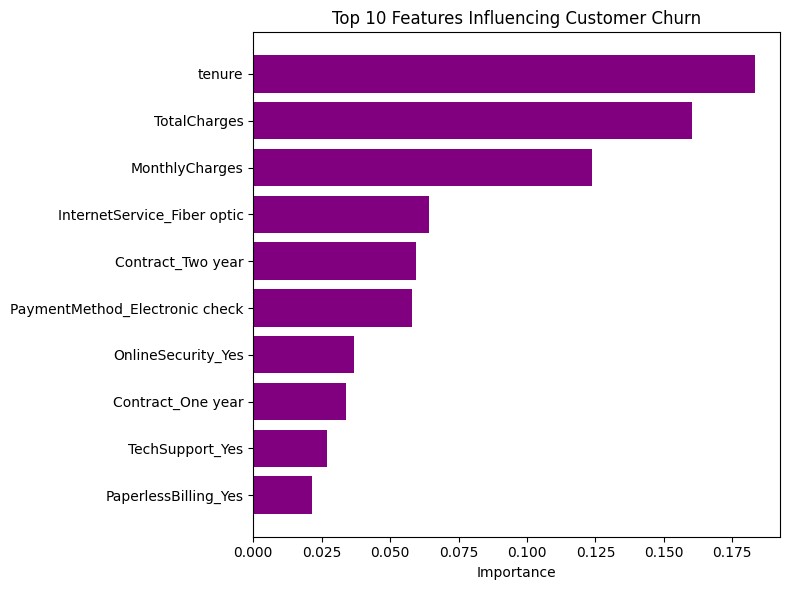

In [112]:
# Top 10 Important Features
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="purple"
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Final Model Summary

In [113]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        log_precision,
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        log_recall,
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1-Score": [
        log_f1,
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

final_results.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.805,0.650,0.575,0.610
1,Decision Tree,0.719,0.470,0.463,0.466
2,Random Forest,0.787,0.622,0.511,0.561
3,Tuned Random Forest,0.790,0.630,0.511,0.564


Note: 
Please refer to the accompanying white paper for detailed explanations of the project methodology, analysis, and findings.